# Fixed-size chunking

Reads every PDF in `data/raw/kvaliteket/` and splits each into fixed-size chunks.

The PDFs are real HR documents and notebook outputs are saved in this file: only print counts and statistics here, never chunk text.

In [ ]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / "src" / "backend" / "ai"))
sys.path.insert(0, str(REPO_ROOT / "src" / "backend" / "ai" / "chunking"))

from pdf_reader import read_all_pdfs
from fixed_chunking import chunk_by_fixed_size, DEFAULT_CHUNK_SIZE

In [2]:
documents = read_all_pdfs(REPO_ROOT / "data" / "raw" / "kvaliteket")

chunks = [
    chunk
    for document in documents
    for chunk in chunk_by_fixed_size(document["words"], document["source_pdf"])
]

In [3]:
from statistics import mean, median, pstdev

words_per_chunk = [
    len(chunk["text"].split())
    for chunk in chunks
]

print(
    f"{len(documents)} documents -> {len(chunks)} chunks "
    f"(chunk size {DEFAULT_CHUNK_SIZE})"
)

print(f"Total words: {sum(words_per_chunk)}")
print(f"Average chunks per document: {len(chunks) / len(documents):.1f}")

print("\nWords per chunk:")
print(f"  min:    {min(words_per_chunk)}")
print(f"  max:    {max(words_per_chunk)}")
print(f"  mean:   {mean(words_per_chunk):.1f}")
print(f"  median: {median(words_per_chunk):.1f}")
print(f"  std:    {pstdev(words_per_chunk):.1f}")

137 documents -> 1142 chunks (chunk size 80)
Total words: 86670
Average chunks per document: 8.3

Words per chunk:
  min:    1
  max:    93
  mean:   75.9
  median: 80.0
  std:    14.4


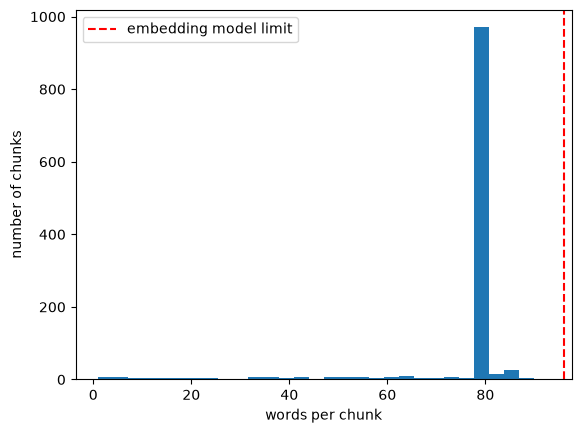

In [5]:
import matplotlib.pyplot as plt

EMBEDDING_MODEL_WORD_LIMIT = 96

plt.hist(words_per_chunk, bins=30)
plt.axvline(EMBEDDING_MODEL_WORD_LIMIT, color="red", linestyle="--", label="embedding model limit")
plt.xlabel("words per chunk")
plt.ylabel("number of chunks")
plt.legend()
plt.show()